<a href="https://colab.research.google.com/github/NazarenoSiciliano/Data-Science-II/blob/main/%20Entrega%20Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Data Science: Análisis de Cobertura de Vacunación (SRP) y Riesgo Epidemiológico en la Provincia de Buenos Aires

## Abstracto y Motivación
El sarampión es una enfermedad viral altamente contagiosa que puede resurgir rápidamente si las tasas de vacunación poblacional disminuyen. Para prevenir brotes y mantener la conocida "inmunidad de rebaño", la Organización Mundial de la Salud (OMS) establece que la cobertura de la vacuna Triple Viral (SRP - Sarampión, Rubéola y Paperas) debe mantenerse de forma sostenida por encima del 95%.

La motivación principal de este proyecto es analizar la evolución histórica (período 2009-2018) de la cobertura de vacunación de la primera y segunda dosis en la Provincia de Buenos Aires. Al identificar patrones, tendencias a la baja y brechas entre las dosis aplicadas, el objetivo final es sentar las bases para entrenar modelos de Machine Learning capaces de predecir o alertar sobre zonas y períodos de alto riesgo epidemiológico ante la posible aparición de un caso índice.

## Audiencia
Este análisis está dirigido a:
* **Ministerio de Salud y Secretarías de Salud Municipales:** Para optimizar la toma de decisiones en políticas públicas y asignación de recursos.
* **Equipos de Vigilancia Epidemiológica:** Para focalizar y dirigir campañas de vacunación territoriales en los años o regiones donde se detecte una baja adherencia al calendario de vacunación, previniendo así futuros brotes.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ❓ Preguntas e Hipótesis a Responder

El presente análisis busca responder las siguientes interrogantes clave sobre la situación inmunológica de la Provincia de Buenos Aires respecto al sarampión:

1. **Cumplimiento del umbral de seguridad (Hipótesis de riesgo):** * *Pregunta:* ¿Logró la Provincia de Buenos Aires mantener el umbral mínimo del 95% de cobertura en la vacuna Triple Viral (SRP) recomendado por la OMS durante el período 2009-2018?
   * *Hipótesis:* Suponemos que existen múltiples años donde la cobertura perforó el piso del 95%, generando ventanas de vulnerabilidad epidemiológica (bolsas de susceptibles).

2. **Adherencia al calendario de vacunación (Brecha entre dosis):**
   * *Pregunta:* ¿Existe una caída significativa en el porcentaje de aplicación entre la primera dosis (a los 12 meses de edad) y la segunda dosis (al ingreso escolar)?
   * *Hipótesis:* Se espera observar una menor cobertura en la segunda dosis debido a la falta de seguimiento o barreras de acceso al sistema de salud a medida que el niño crece.

3. **Detección de períodos críticos (Análisis temporal):**
   * *Pregunta:* ¿Cuáles fueron los años de mayor riesgo epidemiológico debido a las bajas tasas de inmunización general?
   * *Hipótesis:* Los años con caídas abruptas en la vacunación preceden estadísticamente a los brotes de enfermedades inmunoprevenibles.

4. **Proyección y Modelado (Visión a futuro para Machine Learning):**
   * *Pregunta:* ¿Es posible predecir tendencias de baja cobertura en años futuros analizando el comportamiento histórico de estas dos dosis?
   * *Hipótesis:* Entrenando un modelo de Machine Learning con el historial de coberturas y variables temporales, podremos alertar de forma temprana sobre futuras caídas en la vacunación.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df_vacunas = pd.read_csv('/content/drive/MyDrive/dicei-vacunas-srp-2009-2018.csv')

print("Dimensiones del dataset:", df_vacunas.shape)
display(df_vacunas.head())

Dimensiones del dataset: (24, 22)


,jurisdiccion_id,jurisdiccion_nombre,2009_cob_ 1_ dosis_12_meses,2009_cob_ 2_ dosis_ingreso_escolar,2010_cob_ 1_ dosis_12_meses,2010_cob_ 2_ dosis_ingreso_escolar,2011_cob_ 1_ dosis_12_meses,2011_cob_ 2_ dosis_ingreso_escolar,2012_cob_ 1_ dosis_12_meses,2012_cob_ 2_ dosis_ingreso_escolar,...,2014_cob_ 1_ dosis_al_12_meses,2014_cob_ 2_ dosis_ingreso_escolar,2015_cob_ 1_ dosis_12_meses,2015_cob_ 2_ dosis_ingreso_escolar,2016_cob_ 1_ dosis_12_meses,2016_cob_ 2_ dosis_ingreso_escolar,2017_cob_ 1_ dosis_12_meses,2017_cob_ 2_ dosis_ingreso_escolar,2018_cob_ 1_ dosis_12_meses,2018_cob_ 2_ dosis_ingreso_escolar
0,6,BUENOS AIRES,105.4,98.8,108.6,105.2,93.0,94.1,89.9,90.1,...,97.7,101.0,85.2,85.5,90.9,88.5,91.5,89.9,99.2,99.4
1,2,CABA,95.0,95.3,96.5,90.1,91.6,103.0,92.6,91.5,...,83.8,86.8,73.6,70.5,83.5,76.1,81.7,80.8,97.7,99.7
2,10,CATAMARCA,112.7,95.6,93.8,92.7,82.7,74.2,85.5,78.8,...,89.9,96.6,98.4,84.5,95.0,85.2,90.3,89.7,96.0,110.8
3,22,CHACO,107.1,87.4,100.7,106.6,104.4,89.4,94.0,89.0,...,99.2,85.6,100.3,83.1,91.1,76.7,97.9,112.6,95.3,92.6
4,26,CHUBUT,92.6,106.1,93.7,66.4,101.1,98.1,98.4,90.7,...,103.2,102.2,98.1,109.4,96.0,99.7,94.6,95.0,99.1,101.8


El dataset original tiene los años como columnas (formato wide). Para graficar y analizar, necesitamos transformarlo (formato long). Vamos a enfocarnos en la Provincia de Buenos Aires.

In [9]:

df_pba = df_vacunas[df_vacunas['jurisdiccion_nombre'] == 'BUENOS AIRES'].copy()

df_pba_melted = df_pba.melt(id_vars=['jurisdiccion_id', 'jurisdiccion_nombre'],
                            var_name='anio_dosis',
                            value_name='cobertura_pct')


df_pba_melted['anio'] = df_pba_melted['anio_dosis'].str.split('_').str[0].astype(int)

def clasificar_dosis(texto):
    if '1_ dosis' in texto:
        return '1ra Dosis (12 meses)'
    else:
        return '2da Dosis (Ingreso Escolar)'

df_pba_melted['tipo_dosis'] = df_pba_melted['anio_dosis'].apply(clasificar_dosis)

df_pba_clean = df_pba_melted[['jurisdiccion_nombre', 'anio', 'tipo_dosis', 'cobertura_pct']]

print("Datos limpios y transformados:")
display(df_pba_clean.head())

Datos limpios y transformados:


,jurisdiccion_nombre,anio,tipo_dosis,cobertura_pct
0,BUENOS AIRES,2009,1ra Dosis (12 meses),105.4
1,BUENOS AIRES,2009,2da Dosis (Ingreso Escolar),98.8
2,BUENOS AIRES,2010,1ra Dosis (12 meses),108.6
3,BUENOS AIRES,2010,2da Dosis (Ingreso Escolar),105.2
4,BUENOS AIRES,2011,1ra Dosis (12 meses),93.0


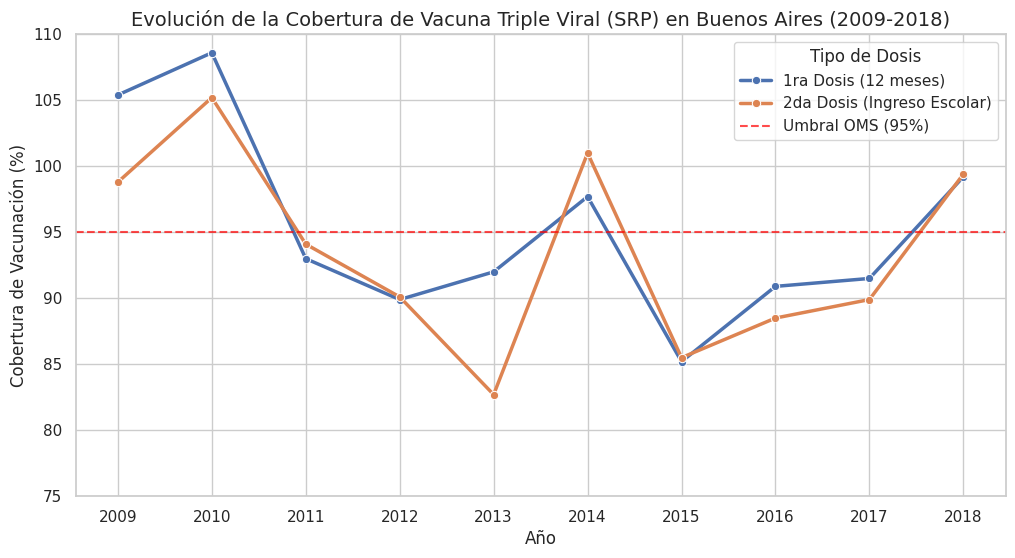

Insight: El punto más bajo de cobertura se registró en el año 2013 con un 82.7%.


In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_pba_clean, x='anio', y='cobertura_pct', hue='tipo_dosis', marker='o', linewidth=2.5)

plt.axhline(95, color='red', linestyle='--', alpha=0.7, label='Umbral OMS (95%)')

plt.title('Evolución de la Cobertura de Vacuna Triple Viral (SRP) en Buenos Aires (2009-2018)', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cobertura de Vacunación (%)', fontsize=12)
plt.xticks(df_pba_clean['anio'].unique())
plt.legend(title='Tipo de Dosis')
plt.ylim(75, 110)

plt.savefig('evolucion_vacunacion_pba.png', dpi=300)
plt.show()

min_cobertura = df_pba_clean['cobertura_pct'].min()
anio_min_cob = df_pba_clean.loc[df_pba_clean['cobertura_pct'].idxmin(), 'anio']
print(f"Insight: El punto más bajo de cobertura se registró en el año {anio_min_cob} con un {min_cobertura}%.")

## 1. Ampliación del Análisis Exploratorio de Datos (EDA)
Tomando en cuenta el feedback recibido, ampliaremos el análisis para incluir a **todas las jurisdicciones** del país. Esto no solo nos dará un panorama nacional, sino que nos proveerá el volumen de datos necesario para entrenar modelos de Machine Learning.

A continuación, visualizaremos la distribución general de la cobertura y compararemos el rendimiento de la 1ra Dosis vs. la 2da Dosis a nivel nacional.

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_10038/1823948117.py:7: SyntaxWarning: invalid escape sequence '\d'
  df_melted['anio'] = df_melted['anio_dosis'].str.extract('(\d{4})').astype(int)


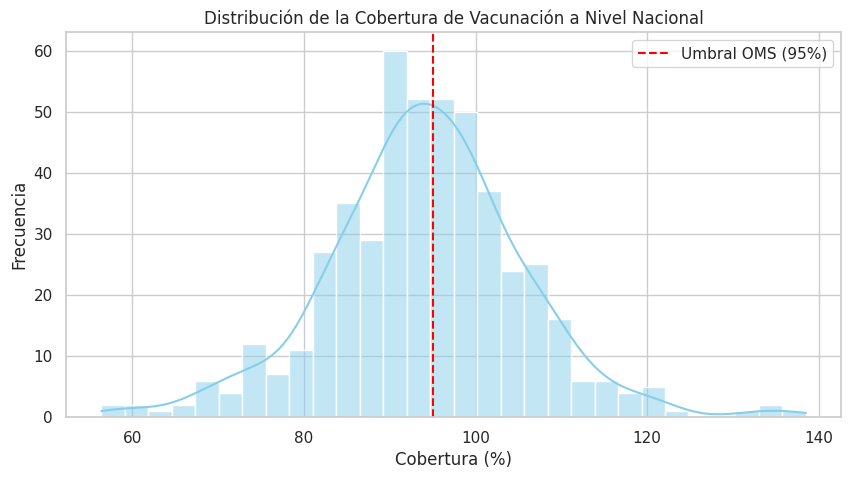

/tmp/ipykernel_10038/1823948117.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='tipo_dosis', y='cobertura_pct', palette='Set2')


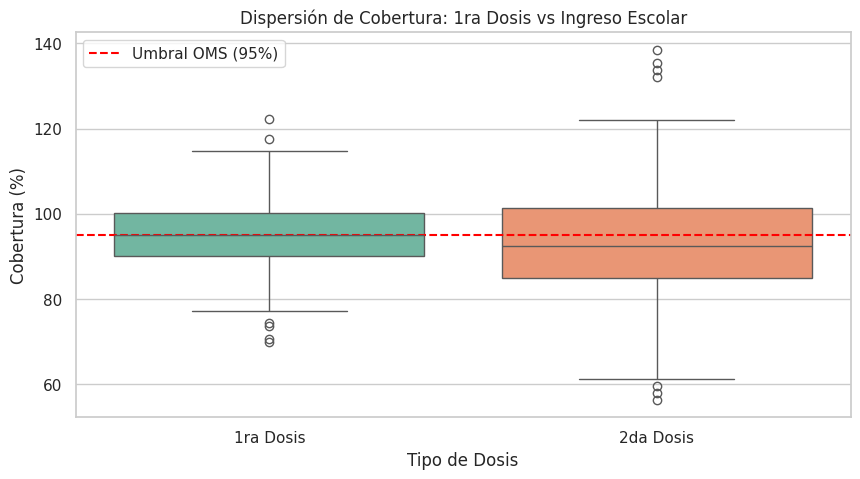

In [11]:
# Preparación del dataset completo (todas las provincias)
df_melted = df_vacunas.melt(id_vars=['jurisdiccion_id', 'jurisdiccion_nombre'],
                            var_name='anio_dosis',
                            value_name='cobertura_pct')

# Extraemos el año numérico y el tipo de dosis
df_melted['anio'] = df_melted['anio_dosis'].str.extract('(\d{4})').astype(int)
df_melted['tipo_dosis'] = df_melted['anio_dosis'].apply(lambda x: '1ra Dosis' if '1_ dosis' in x else '2da Dosis')

# Eliminamos valores nulos si los hubiera
df_melted.dropna(inplace=True)

# Gráfico 1: Distribución de la cobertura
plt.figure(figsize=(10, 5))
sns.histplot(df_melted['cobertura_pct'], bins=30, kde=True, color='skyblue')
plt.axvline(95, color='red', linestyle='--', label='Umbral OMS (95%)')
plt.title('Distribución de la Cobertura de Vacunación a Nivel Nacional')
plt.xlabel('Cobertura (%)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# Gráfico 2: Comparación entre Dosis
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_melted, x='tipo_dosis', y='cobertura_pct', palette='Set2')
plt.axhline(95, color='red', linestyle='--', label='Umbral OMS (95%)')
plt.title('Dispersión de Cobertura: 1ra Dosis vs Ingreso Escolar')
plt.xlabel('Tipo de Dosis')
plt.ylabel('Cobertura (%)')
plt.legend()
plt.show()

## 2. Modelado del Problema de Machine Learning
**Variable a predecir (Target):** `riesgo_epidemiologico`
Definimos este problema como uno de **Clasificación Binaria**. Crearemos una nueva variable objetivo que valdrá `1` si la cobertura de vacunación cae por debajo del 95% (Riesgo Alto) y `0` si es igual o superior al 95% (Riesgo Bajo/Seguro).

**Objetivo:** Predecir si una campaña de vacunación en una provincia determinada y para una dosis específica estará en riesgo de no cumplir el objetivo de la OMS, permitiendo actuar de forma preventiva.

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# 1. Creación de la variable objetivo (Target)
df_melted['riesgo_epidemiologico'] = np.where(df_melted['cobertura_pct'] < 95.0, 1, 0)

# 2. Selección de Features (Variables predictoras) y Target
# Descartamos 'jurisdiccion_id' y 'anio_dosis' por ser redundantes, y 'cobertura_pct' porque es la que usamos para crear el target.
X = df_melted[['jurisdiccion_nombre', 'anio', 'tipo_dosis']]
y = df_melted['riesgo_epidemiologico']

# 3. Encoding de variables categóricas (Feedback del profesor)
# One-Hot Encoding para el nombre de la provincia (al no tener un orden lógico)
X_encoded = pd.get_dummies(X, columns=['jurisdiccion_nombre'], drop_first=True)

# Label Encoding para el tipo de dosis (1ra Dosis = 0, 2da Dosis = 1)
le = LabelEncoder()
X_encoded['tipo_dosis'] = le.fit_transform(X_encoded['tipo_dosis'])

# 4. Estandarización de variables numéricas (El año)
scaler = StandardScaler()
X_encoded['anio'] = scaler.fit_transform(X_encoded[['anio']])

print("Dataset procesado y codificado. Variables predictoras:")
display(X_encoded.head())

Dataset procesado y codificado. Variables predictoras:


,anio,tipo_dosis,jurisdiccion_nombre_CABA,jurisdiccion_nombre_CATAMARCA,jurisdiccion_nombre_CHACO,jurisdiccion_nombre_CHUBUT,jurisdiccion_nombre_CORDOBA,jurisdiccion_nombre_CORRIENTES,jurisdiccion_nombre_ENTRE RIOS,jurisdiccion_nombre_FORMOSA,...,jurisdiccion_nombre_NEUQUEN,jurisdiccion_nombre_RIO NEGRO,jurisdiccion_nombre_SALTA,jurisdiccion_nombre_SAN JUAN,jurisdiccion_nombre_SAN LUIS,jurisdiccion_nombre_SANTA CRUZ,jurisdiccion_nombre_SANTA FE,jurisdiccion_nombre_SANTIAGO DEL ESTERO,jurisdiccion_nombre_TIERRA DEL FUEGO,jurisdiccion_nombre_TUCUMAN
0,-1.566699,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,-1.566699,0,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-1.566699,0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-1.566699,0,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-1.566699,0,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 3. División de Datos y Entrenamiento de Algoritmos
Separaremos los datos en un conjunto de entrenamiento (80%) y prueba (20%).
Entrenaremos dos algoritmos robustos para clasificación:
1. **Random Forest Classifier:** Excelente para manejar relaciones no lineales y múltiples variables categóricas codificadas.
2. **XGBoost Classifier:** Un algoritmo de *Gradient Boosting* de alto rendimiento, ideal para optimizar métricas complejas.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# División en Entrenamiento (Train) y Prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Definición de Modelos
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Entrenamiento
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print("¡Modelos entrenados con éxito!")

¡Modelos entrenados con éxito!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:03:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 4. Optimización (GridSearchCV)
Para mejorar el rendimiento de nuestro modelo Random Forest, aplicaremos **GridSearchCV** con validación cruzada (Cross-Validation de 5 particiones). Esto nos asegura encontrar la mejor combinación de hiperparámetros evitando el sobreajuste (*overfitting*).

In [14]:
from sklearn.model_selection import GridSearchCV

# Definimos la grilla de hiperparámetros a explorar para Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

# Configuramos GridSearch con validación cruzada (cv=5)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='roc_auc', # Optimizamos el área bajo la curva
                           n_jobs=-1)

# Entrenamos la búsqueda
grid_search.fit(X_train, y_train)

# Obtenemos el mejor modelo
best_rf = grid_search.best_estimator_

print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")

Mejores hiperparámetros encontrados: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


## 5. Evaluación y Justificación de Métricas
**Justificación:** En el contexto de la salud pública y el riesgo de brotes de sarampión, no solo nos interesa el *Accuracy* (Exactitud). La métrica más crítica aquí es el **Recall (Sensibilidad)** para la clase 1 (Riesgo). Nos resulta mucho más perjudicial predecir que una provincia estará bien y que luego la cobertura caiga (Falso Negativo), que enviar recursos preventivos a una provincia que finalmente sí iba a lograr la meta (Falso Positivo).

Además, evaluaremos el **ROC-AUC** para entender la capacidad general del modelo para separar ambas clases.

--- RESULTADOS RANDOM FOREST OPTIMIZADO ---
ROC-AUC Score: 0.7776
              precision    recall  f1-score   support

           0       0.69      0.72      0.70        46
           1       0.73      0.70      0.71        50

    accuracy                           0.71        96
   macro avg       0.71      0.71      0.71        96
weighted avg       0.71      0.71      0.71        96


--- RESULTADOS XGBOOST ---
ROC-AUC Score: 0.7157
              precision    recall  f1-score   support

           0       0.67      0.67      0.67        46
           1       0.70      0.70      0.70        50

    accuracy                           0.69        96
   macro avg       0.69      0.69      0.69        96
weighted avg       0.69      0.69      0.69        96



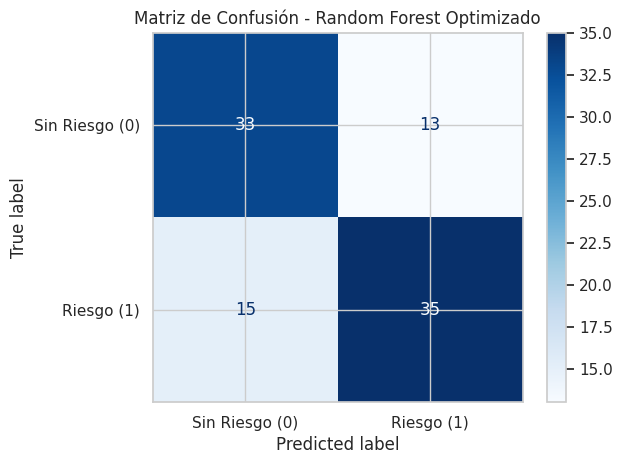

In [15]:
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Predicciones con el mejor modelo de Random Forest
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

# Predicciones con XGBoost base
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Cálculo de AUC
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("--- RESULTADOS RANDOM FOREST OPTIMIZADO ---")
print(f"ROC-AUC Score: {auc_rf:.4f}")
print(classification_report(y_test, y_pred_rf))

print("\n--- RESULTADOS XGBOOST ---")
print(f"ROC-AUC Score: {auc_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb))

# Visualización de la Matriz de Confusión del mejor modelo
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin Riesgo (0)', 'Riesgo (1)'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Random Forest Optimizado')
plt.show()